# DNA Fingerprinting: Gel Electrophoresis Fragment Size Modeling

## Objective & Background
To determine the exact base-pair fragment sizes of unknown plasmid DNA samples via gel electrophoresis, we utilize reference DNA markers with established molecular weights.

For this protocol, we implemented two standardized DNA markers deployed at opposite ends of the gel matrix:
* **Lambda HindIII DNA Marker**
* **1kb DNA Ladder**

---

> **Analytical Strategy:** As DNA migration rates through a gel matrix is inversely proportional to the logarithm of the molecular weight of the sample, this notebook models and contrasts a **Linear Regression Plot** against a **Semi-Logarithmic Regression Plot** (migration distance versus the logarithm of base-pair size). This comparative analysis allows us to empirically determine which mathematical curve provides the most reliable and accurate fit for calculating our unknown fragment sizes.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [10]:
#Molecular weights of DNA markers (Base pairs, bp)
h_size = np.array([23130, 9416, 6557, 4361, 2322, 2027])
k_size = np.array([10000, 8000, 6000, 5000, 4000, 3000, 2000, 1500, 1000, 750, 500])

#Observed migration distances of DNA markers measured from center-bottom of well to band (Millimeters, mm)
h_dist = np.array([41, 47, 53, 62, 79, 83])
k_dist = np.array([46, 49, 53, 57, 61, 68, 73, 79, 89, 104, 115])

#Observed migration distances of experimental samples measured from center-bottom of well to band (Millimeters, mm)
samples = {
    "CS": [60, 64, 70],
    "S1": [70, 77, 98, 107],
    "S2": [70, 77, 98, 107],
    "S3": [58, 62, 69],
    "S4": [69, 100],
    "S5": [69, 79, 100]
}

In [11]:
#We transform the base-pair sizes to log space to linearize the best fit curves
h_log_size = np.log10(h_size)
k_log_size = np.log10(k_size)

#We perform Ordinary Least Squares linear regression where x = migration distance and y = log10(base-pair size)
h_slope, h_intercept, h_r_v, h_p_v, h_std = stats.linregress(h_dist, h_log_size)
k_slope, k_intercept, k_r_v, k_p_v, k_std = stats.linregress(k_dist, k_log_size)

#Square the correlation coefficient (R-value) to calculate Coefficient of Determination (R^2)
h_r2 = h_r_v ** 2
k_r2 = k_r_v ** 2

print(f"HindIII: Gradient = {h_slope:.4f}, R^2 = {h_r2:.4f}")
print(f"1kb Ladder: Gradient = {k_slope:.4f}, R^2 = {k_r2:.4f}")

HindIII: Gradient = -0.0223, R^2 = 0.9259
1kb Ladder: Gradient = -0.0188, R^2 = 0.9708


In [12]:
#Generate 100 evenly spaced steps across distance windows to map a straight best fit line
h_range = np.linspace(min(h_dist), max(h_dist), 100)
k_range = np.linspace(min(k_dist), max(k_dist), 100)

#Invert linear-log model back to standard linear model with formula: base-pair size = 10 ^ (slope * migration distance + y-intercept)
h_fit = 10 ** (h_slope * h_range + h_intercept)
k_fit = 10 ** (k_slope * k_range + k_intercept)

In [13]:
stats_box_text = (f"Lambda HindIII Marker:\n"
                  f"  Gradient: {h_slope:.4f}\n"
                  f"  $R^2$: {h_r2:.4f}\n\n"
                  f"1kb DNA Ladder:\n"
                  f"  Gradient: {k_slope:.4f}\n"
                  f"  $R^2$: {k_r2:.4f}")

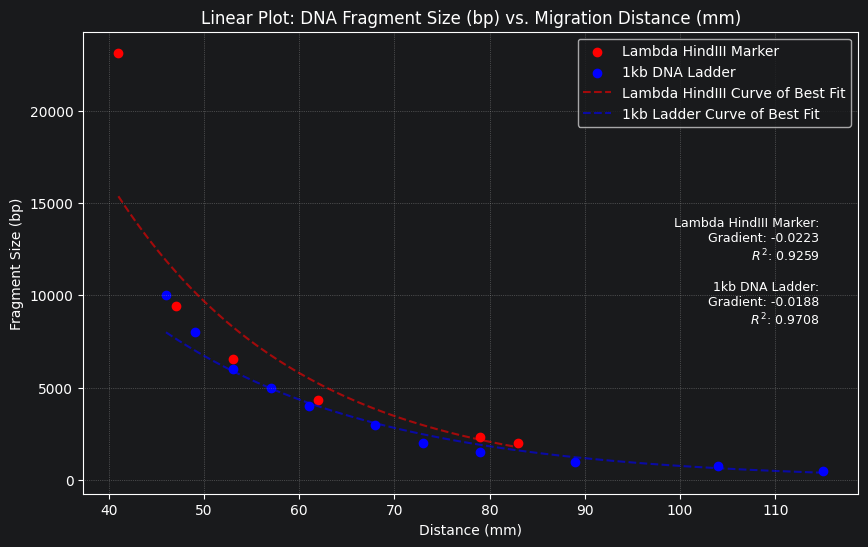

In [14]:
#Comparative Linear Plot
plt.figure(figsize=(10, 6))

#Plot scatter points of raw empirical data points from observation
plt.scatter(h_dist, h_size, color='red', label='Lambda HindIII Marker')
plt.scatter(k_dist, k_size, color='blue', label='1kb DNA Ladder')

#Plot curve of best fit
plt.plot(h_range, h_fit, 'r--', alpha=0.6, label='Lambda HindIII Curve of Best Fit')
plt.plot(k_range, k_fit, 'b--', alpha=0.6, label='1kb Ladder Curve of Best Fit')

#Annotate plot with calculated slope and R^2
plt.text(0.95, 0.6, stats_box_text, transform=plt.gca().transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(alpha=0, edgecolor='gray'))

#Plot formatting
plt.title('Linear Plot: DNA Fragment Size (bp) vs. Migration Distance (mm)')
plt.xlabel('Distance (mm)')
plt.ylabel('Fragment Size (bp)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

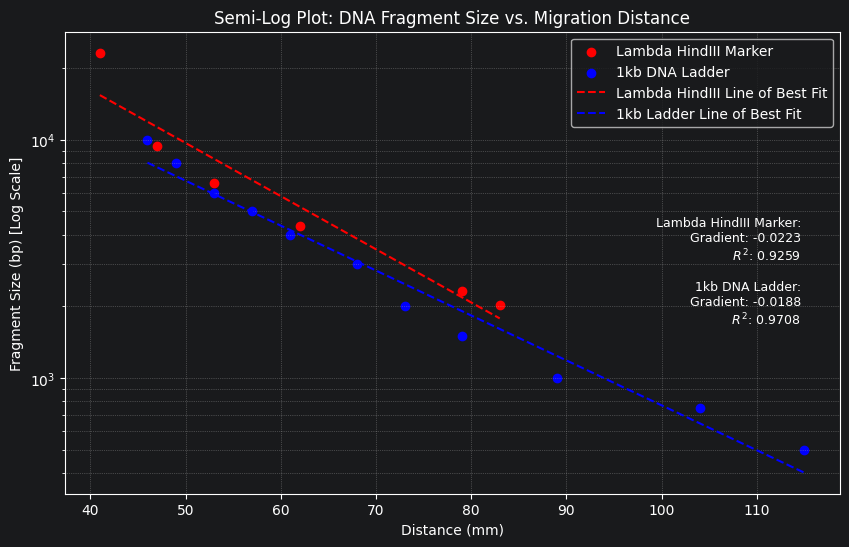

In [15]:
#Comparative Semi-Log Plot
plt.figure(figsize=(10, 6))

#Plot scatter points of raw empirical data points from observation
plt.scatter(h_dist, h_size, color='red', label='Lambda HindIII Marker')
plt.scatter(k_dist, k_size, color='blue', label='1kb DNA Ladder')

#Plot line of best fit
plt.plot(h_range, h_fit, 'r--', label='Lambda HindIII Line of Best Fit')
plt.plot(k_range, k_fit, 'b--', label='1kb Ladder Line of Best Fit')

#Annotate plot with calculated slope and R^2
plt.text(0.95, 0.6, stats_box_text, transform=plt.gca().transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(alpha=0, edgecolor='gray'))

#Canvas formatting
plt.yscale('log')
plt.title('Semi-Log Plot: DNA Fragment Size vs. Migration Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('Fragment Size (bp) [Log Scale]')
plt.legend()
plt.grid(True, which='both', linestyle=':', alpha=0.6)

plt.show()

## Evaluation and Discussion

### Linear versus Semi-Logarithmic Regression
As base-pair sizes have an inverse logarithmic relation with the migration distance, a linearized regression fit represented using a semi-logarithmic plot allows for much easier comparison as well as base-pair calculation for the experimental samples

### Lambda HindIII versus 1kb DNA Ladder
We can see that the 1kb DNA Ladder's regression fit has a higher Coefficient of Determination than that of the Lambda HindIII Marker. This alongside it's higher band density and more uniform band distribution makes it significantly more reliable when estimating base-pair sizes.

In [16]:
summary_list = []

#Loop through experimental measurements to solve for unknown base-pair sizes using the formula: base-pair size = 10 ^ (slope(1kb DNA Ladder) * migration distance + y-intercept(1kb DNA Ladder)
for name, distances in samples.items():
    print(f"Results for {name}:")
    for d in distances:
        log_bp = k_slope * d + k_intercept
        approx_bp = 10 ** log_bp

        print(f"  Migration: {d}mm  ->  Approx. Size: {approx_bp:.0f} bp")
        summary_list.append({"Sample": name, "Distance_mm": d, "Size_bp": round(approx_bp)})
    print("-" * 3)

Results for CS:
  Migration: 60mm  ->  Approx. Size: 4360 bp
  Migration: 64mm  ->  Approx. Size: 3666 bp
  Migration: 70mm  ->  Approx. Size: 2826 bp
---
Results for S1:
  Migration: 70mm  ->  Approx. Size: 2826 bp
  Migration: 77mm  ->  Approx. Size: 2086 bp
  Migration: 98mm  ->  Approx. Size: 839 bp
  Migration: 107mm  ->  Approx. Size: 568 bp
---
Results for S2:
  Migration: 70mm  ->  Approx. Size: 2826 bp
  Migration: 77mm  ->  Approx. Size: 2086 bp
  Migration: 98mm  ->  Approx. Size: 839 bp
  Migration: 107mm  ->  Approx. Size: 568 bp
---
Results for S3:
  Migration: 58mm  ->  Approx. Size: 4755 bp
  Migration: 62mm  ->  Approx. Size: 3998 bp
  Migration: 69mm  ->  Approx. Size: 2951 bp
---
Results for S4:
  Migration: 69mm  ->  Approx. Size: 2951 bp
  Migration: 100mm  ->  Approx. Size: 769 bp
---
Results for S5:
  Migration: 69mm  ->  Approx. Size: 2951 bp
  Migration: 79mm  ->  Approx. Size: 1913 bp
  Migration: 100mm  ->  Approx. Size: 769 bp
---
